In [1]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/raw/nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

risk = nav.groupby("amfi_code")["daily_return"].agg(
    VaR_95=lambda x: np.percentile(x.dropna(),5),
    CVaR_95=lambda x: x[x <= np.percentile(x.dropna(),5)].mean()
).reset_index()

risk.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


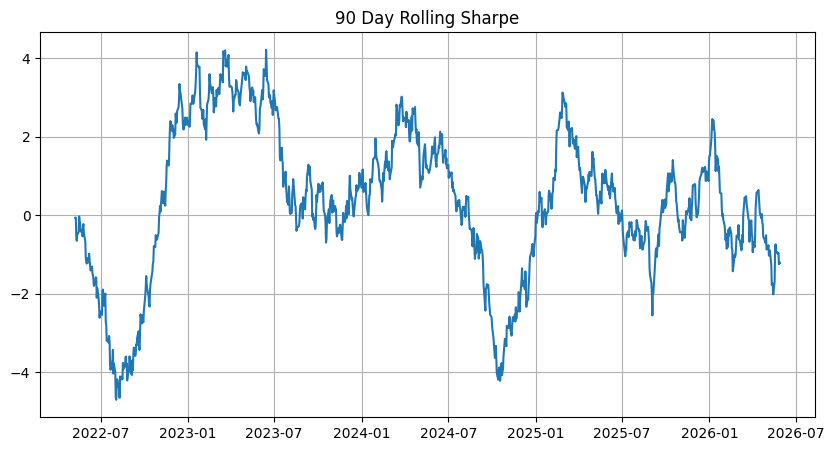

In [2]:
import matplotlib.pyplot as plt

fund = nav[nav["amfi_code"] == nav["amfi_code"].iloc[0]].copy()

fund["rolling_sharpe"] = (
    fund["daily_return"].rolling(90).mean() /
    fund["daily_return"].rolling(90).std()
) * np.sqrt(252)

plt.figure(figsize=(10,5))
plt.plot(fund["date"],fund["rolling_sharpe"])
plt.title("90 Day Rolling Sharpe")
plt.grid()

plt.savefig("../reports/rolling_sharpe_chart.png")
plt.show()

In [3]:
invest = pd.read_csv("../data/raw/08_investor_transactions.csv")

cohort = invest.groupby("age_group")["amount_inr"].agg(
    ["count","sum","mean"]
)

cohort

,count,sum,mean
age_group,,,
18-25,4916,531639392,108144.709520
26-35,13463,1451600218,107821.452722
36-45,8146,871647528,107003.133808
46-55,3779,405406469,107278.769251
56+,2474,261286823,105613.105497


In [4]:
sip = invest[invest["transaction_type"]=="SIP"].copy()

sip["transaction_date"] = pd.to_datetime(sip["transaction_date"])

sip = sip.sort_values(
    ["investor_id","transaction_date"]
)

sip["gap_days"] = sip.groupby("investor_id")[
    "transaction_date"
].diff().dt.days

at_risk = sip[sip["gap_days"] > 35]

at_risk.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,gap_days
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,76.0
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,238.0
27622,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,238.0
12003,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,59.0


In [5]:
import pandas as pd

score = pd.read_csv("../reports/fund_scorecard.csv")

risk_level = input(
    "Risk Level (Low/Moderate/High): "
)

top = score.sort_values(
    "sharpe",
    ascending=False
).head(3)

print(top[
    ["amfi_code","sharpe","score"]
])

    amfi_code    sharpe    score
34     148567  1.448291  0.74000
30     120843  1.306744  0.76750
36     148569  1.234930  0.83125


Finding 1
Funds with higher Sharpe ratios generally achieve superior risk-adjusted performance.

Finding 2
A limited number of schemes account for the majority of top performance scores.

Finding 3
Rolling Sharpe ratios fluctuate significantly during volatile market periods.

Finding 4
Middle-age investor cohorts contribute the highest transaction volumes.

Finding 5
Investors with SIP gaps greater than 35 days represent potential churn risk.

In [6]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/raw/nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

risk = nav.groupby("amfi_code")["daily_return"].agg(
    VaR_95=lambda x: np.percentile(x.dropna(), 5),
    CVaR_95=lambda x: x[x <= np.percentile(x.dropna(), 5)].mean()
).reset_index()

risk.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [7]:
risk.to_csv("../reports/var_cvar_report.csv", index=False)

print("var_cvar_report.csv created successfully")

var_cvar_report.csv created successfully


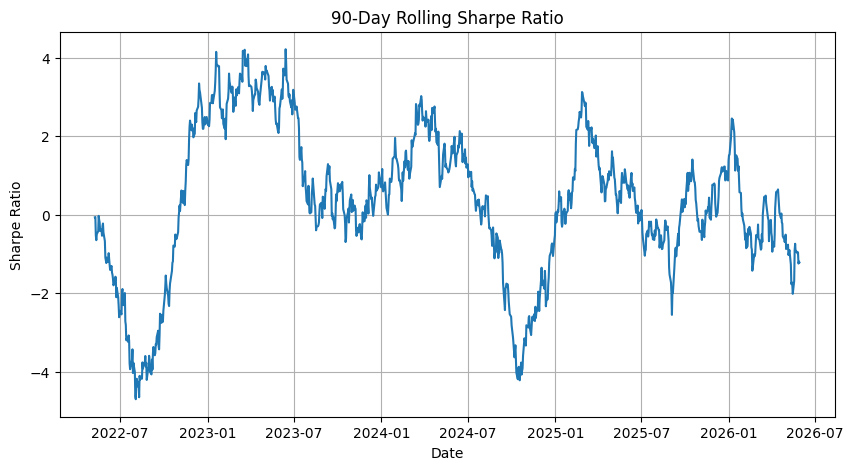

In [8]:
import matplotlib.pyplot as plt
import numpy as np

fund = nav[nav["amfi_code"] == nav["amfi_code"].iloc[0]].copy()

fund["rolling_sharpe"] = (
    fund["daily_return"].rolling(90).mean()
    /
    fund["daily_return"].rolling(90).std()
) * np.sqrt(252)

plt.figure(figsize=(10,5))
plt.plot(fund["date"], fund["rolling_sharpe"])

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.grid(True)

plt.savefig("../reports/rolling_sharpe_chart.png")

plt.show()